# Pipeline Demo — Uçtan Uca Akış

3 mock hasta için `run_pipeline()` çalıştırır ve sonuçları JSON olarak kaydeder.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'sleepfm_interpretability', 'src'))
# Alternatif yol
sys.path.insert(0, os.path.join('..', 'src'))

In [2]:
import json
import umap
import hdbscan
from mock_data import generate_mock_embeddings
from pipeline import run_pipeline

# Mock veri üret
embeddings, labels = generate_mock_embeddings(seed=42, n_samples=500)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")

Embeddings shape: (500, 128)
Labels shape: (500,)


In [3]:
# UMAP + HDBSCAN fit
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_2d = reducer.fit_transform(embeddings)
print(f"UMAP shape: {umap_2d.shape}")

clusterer = hdbscan.HDBSCAN(min_cluster_size=15, prediction_data=True)
clusterer.fit(umap_2d)
n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
print(f"HDBSCAN: {n_clusters} küme bulundu")

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (500, 2)
HDBSCAN: 12 küme bulundu


In [4]:
# 3 sorgu hasta için pipeline çalıştır
results = []
for i in [0, 100, 200]:
    result = run_pipeline(
        query_embedding=embeddings[i],
        reference_embeddings=embeddings,
        reference_labels=labels,
        umap_reducer=reducer,
        hdbscan_model=clusterer,
        patient_id=f"mock_{i:03d}",
    )
    results.append(result)
    print(json.dumps(result, indent=2))
    print("-" * 60)

{
  "patient_id": "mock_000",
  "timestamp": "2026-04-16T23:01:42",
  "embedding_norm": 1.0,
  "umap_coords": [
    -7.8071,
    -0.5477
  ],
  "cluster_id": 0,
  "top5_diseases": [
    {
      "rank": 1,
      "disease": "Obesity",
      "similarity": 0.7838,
      "n_votes": 7
    },
    {
      "rank": 2,
      "disease": "Obstructive Sleep Apnea",
      "similarity": 0.7464,
      "n_votes": 1
    },
    {
      "rank": 3,
      "disease": "Depression",
      "similarity": 0.7462,
      "n_votes": 1
    },
    {
      "rank": 4,
      "disease": "Type 2 Diabetes",
      "similarity": 0.7446,
      "n_votes": 1
    }
  ],
  "modality_scores": {
    "eeg": 0.0257,
    "ecg": 0.1168,
    "resp": 0.0634,
    "emg": 0.0348
  }
}
------------------------------------------------------------
{
  "patient_id": "mock_100",
  "timestamp": "2026-04-16T23:01:42",
  "embedding_norm": 1.0,
  "umap_coords": [
    10.5474,
    10.2476
  ],
  "cluster_id": 8,
  "top5_diseases": [
    {
      "rank":

In [5]:
# JSON dosyasına yaz
os.makedirs('../outputs', exist_ok=True)
output_path = '../outputs/pipeline_demo.json'
with open(output_path, 'w') as f:
    json.dump(results, f, indent=2)

# Doğrulama: geri oku ve parse et
with open(output_path) as f:
    loaded = json.load(f)
assert len(loaded) == 3, "JSON'da 3 hasta olmalı"
print(f"JSON başarıyla kaydedildi → {output_path}")
print(f"Kayıtlı hasta sayısı: {len(loaded)}")

JSON başarıyla kaydedildi → ../outputs/pipeline_demo.json
Kayıtlı hasta sayısı: 3


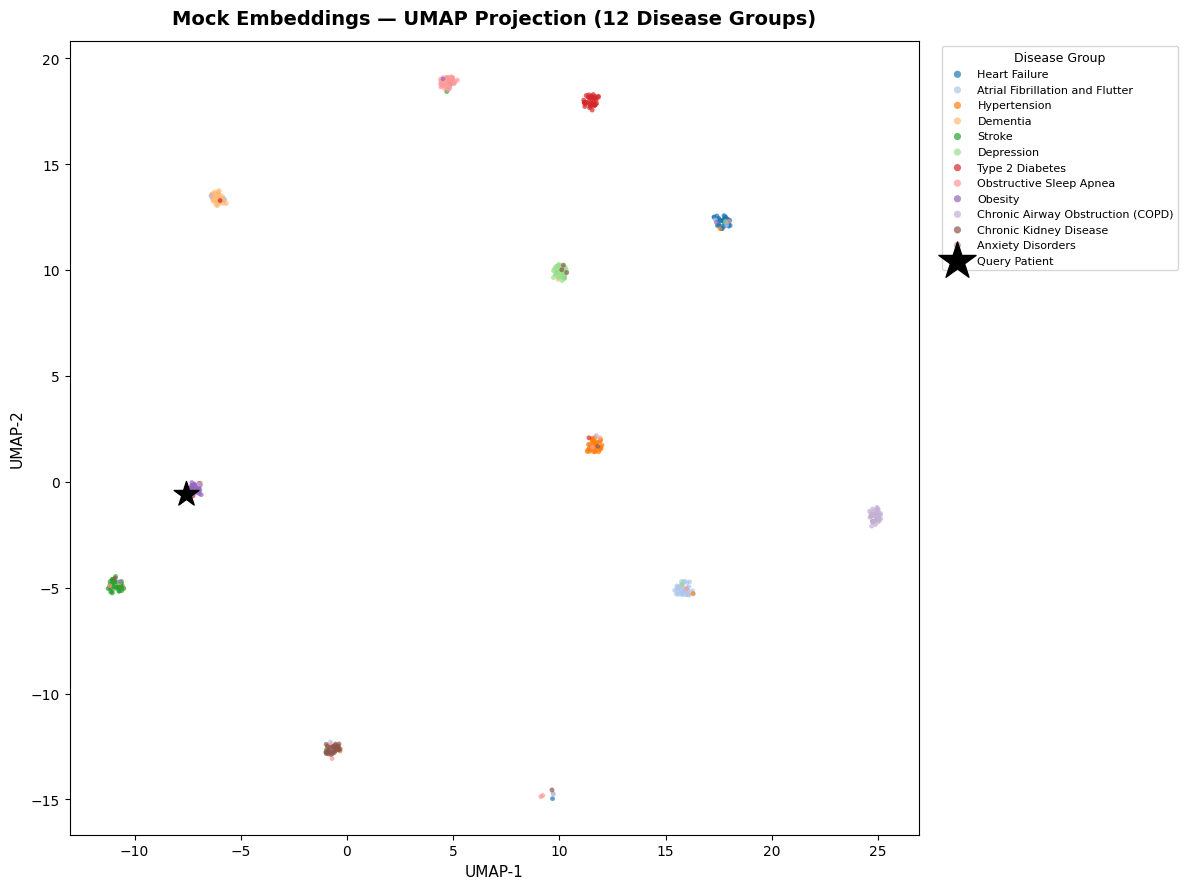

UMAP scatter → ../outputs/mock_umap.png


In [6]:
from visualization import plot_umap_scatter
from config import DISEASE_NAMES

os.makedirs('../outputs', exist_ok=True)

# UMAP scatter — tüm 500 örnek, ilk query hasta (index 0) yıldızla işaretli
plot_umap_scatter(
    umap_coords=umap_2d,
    labels=labels,
    disease_names=DISEASE_NAMES,
    title="Mock Embeddings — UMAP Projection (12 Disease Groups)",
    highlight_idx=0,
    save_path='../outputs/mock_umap.png',
)
print("UMAP scatter → ../outputs/mock_umap.png")

## Visualization — Modality Importance Heatmap

12 × 4 matrix: each row = disease, each column = modality. Cell value = mean |weight| for that modality's dimension range.

In [ ]:
import numpy as np
from mock_data import build_disease_weight_profiles
from config import DISEASES, MODALITY_DIM_RANGES
from visualization import plot_modality_importance_heatmap

profiles = build_disease_weight_profiles()

disease_list = [d.name_en for d in DISEASES.values()]
modality_list = ["eeg", "ecg", "resp", "emg"]

weight_matrix = np.zeros((len(disease_list), len(modality_list)))
for i, disease_name in enumerate(disease_list):
    for j, mod in enumerate(modality_list):
        start, end = MODALITY_DIM_RANGES[mod]
        weight_matrix[i, j] = np.abs(profiles[disease_name][start:end]).mean()

plot_modality_importance_heatmap(
    weight_matrix=weight_matrix,
    disease_names=disease_list,
    modality_names=["EEG", "ECG", "Resp", "EMG"],
    title="Mock Modality Importance Matrix (12 Diseases × 4 Modalities)",
    save_path='../outputs/mock_modality_importance.png',
)
print("Heatmap → ../outputs/mock_modality_importance.png")